# Monte Carlo Pricing & Option Pricing Intuition

This notebook provides numerical Monte Carlo options pricing simulators, convergence rate assessments, and a complete geometric visualization of the **Four-Panel option pricing framework** matching **Part 5: Monte Carlo & Option Pricing Intuition**.

We use **Matplotlib** for all charts to ensure they are fully pre-rendered and visible when viewed directly on GitHub.

In [1]:
import numpy as np
from scipy.stats import norm, lognorm
import matplotlib.pyplot as plt

# Set plot styling for professional look
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 14
})
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Monte Carlo Pricing SDE and Algorithms

We implement the Monte Carlo pricing engine for European call and put options under the continuous dividend yield $q$:
1. **Plain Monte Carlo**: Randomly samples $N$ standard normal variables $Z^{(i)} \sim \mathcal{N}(0, 1)$ to simulate terminal stock price path $S_T^{(i)}$.
2. **Antithetic Variates Monte Carlo**: A variance-reduction technique that pairs each sample $Z^{(i)}$ with its mirror image $-Z^{(i)}$ to cancel out random noise and accelerate convergence.

In [2]:
def bs_call_analytical(S0, K, T, r, q, sigma):
    if T <= 0:
        return max(S0 - K, 0.0)
    d1 = (np.log(S0/K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def mc_pricing(S0, K, T, r, q, sigma, N, option_type='call', antithetic=True):
    np.random.seed(42)
    if antithetic:
        # Sample half the size and append their negative opposites
        half_N = N // 2
        Z_half = np.random.normal(size=half_N)
        Z = np.concatenate([Z_half, -Z_half])
    else:
        Z = np.random.normal(size=N)
        
    # Terminal stock prices
    S_T = S0 * np.exp((r - q - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    
    # Evaluate payoffs
    if option_type.lower() == 'call':
        payoffs = np.maximum(S_T - K, 0.0)
    else:
        payoffs = np.maximum(K - S_T, 0.0)
        
    # Discount back to today
    price = np.exp(-r * T) * np.mean(payoffs)
    return price

## 2. Convergence Analysis

We analyze the convergence rate by plotting pricing errors against the number of simulation paths $N$, comparing **Plain MC** with **Antithetic Variates**.

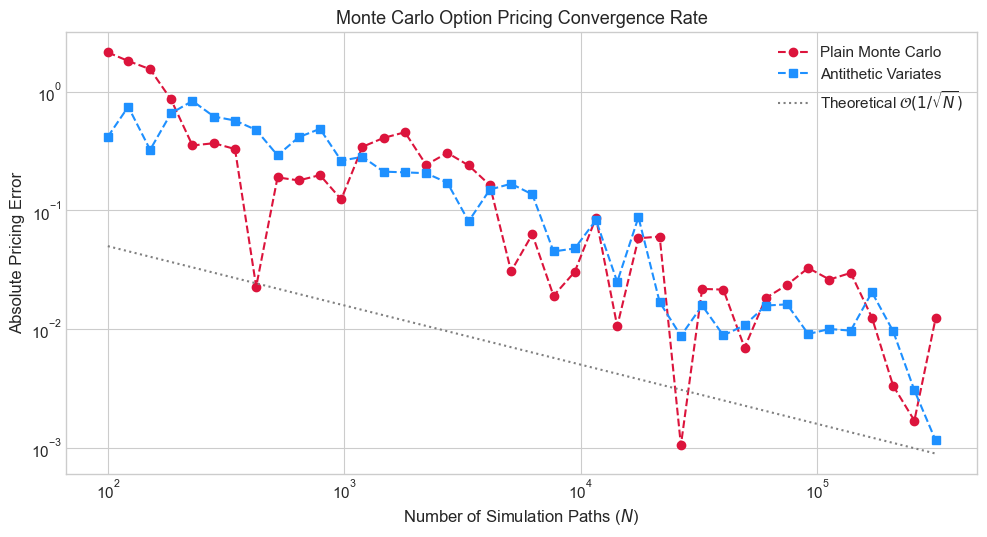

In [3]:
# Reference Parameters
S0, K, T, r, q, sigma = 100.0, 100.0, 1.0, 0.05, 0.02, 0.20
exact_price = bs_call_analytical(S0, K, T, r, q, sigma)

Ns = np.unique(np.logspace(2, 5.5, 40).astype(int))
errors_plain = []
errors_antith = []

for N in Ns:
    p_plain = mc_pricing(S0, K, T, r, q, sigma, N, option_type='call', antithetic=False)
    p_antith = mc_pricing(S0, K, T, r, q, sigma, N, option_type='call', antithetic=True)
    errors_plain.append(abs(p_plain - exact_price))
    errors_antith.append(abs(p_antith - exact_price))

# Plot error convergence on a log-log scale
plt.figure(figsize=(10, 5.5))
plt.loglog(Ns, errors_plain, 'o--', color='crimson', label='Plain Monte Carlo')
plt.loglog(Ns, errors_antith, 's--', color='dodgerblue', label='Antithetic Variates')
plt.loglog(Ns, 0.5 / np.sqrt(Ns), ':', color='grey', label=r"Theoretical $\mathcal{O}(1/\sqrt{N})$")
plt.title("Monte Carlo Option Pricing Convergence Rate")
plt.xlabel(r"Number of Simulation Paths ($N$)")
plt.ylabel("Absolute Pricing Error")
plt.legend()
plt.tight_layout()
plt.show()


## 3. The Four-Panel Visualization

We geometrically reconstruct the option pricing integral as the **area under the Contribution Curve** using a $2 \times 2$ grid plot:
*   **Panel A: Future Price Distribution** - The risk-neutral lognormal PDF $f_{\mathbb{Q}}(S_T)$.
*   **Panel B: Discounted Density** - Probability weighted by present value discount factor $e^{-rT} f_{\mathbb{Q}}(S_T)$.
*   **Panel C: Option Payoff Overlay** - The Call option payoff $\max(S_T - K, 0)$.
*   **Panel D: The Contribution Curve** - The product of Panel B and Panel C, where the **Call option price** is represented by the shaded area under the curve.

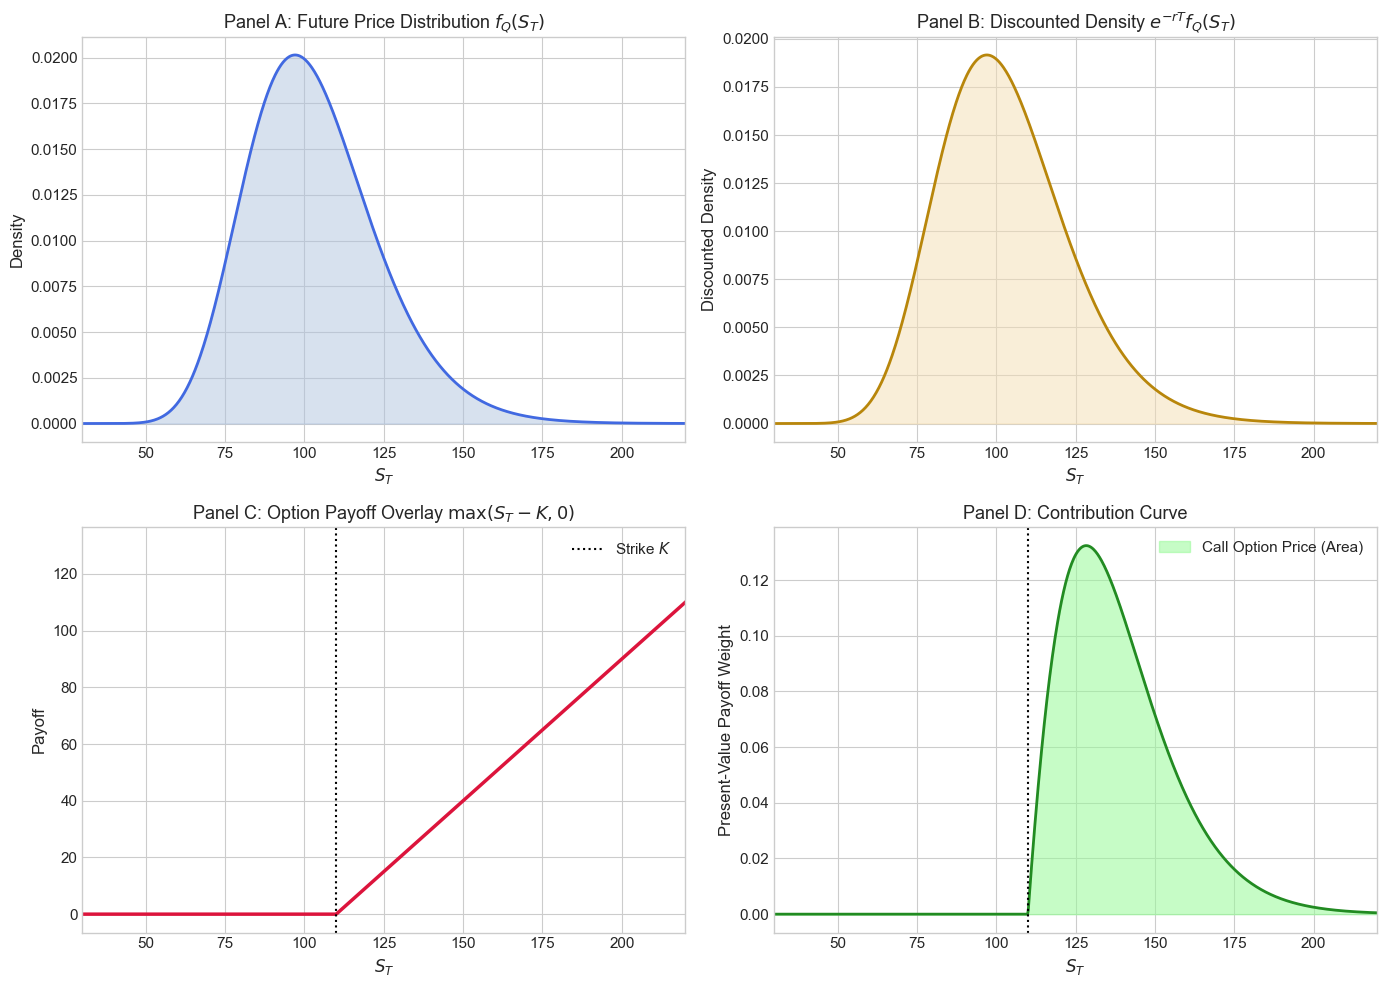

In [4]:
# Slightly OTM call for a clean visual separation
S0, K, T, r, q, sigma = 100.0, 110.0, 1.0, 0.05, 0.02, 0.20

S_grid = np.linspace(30, 240, 1000)
mu_l = np.log(S0) + (r - q - 0.5 * sigma**2) * T
sigma_l = sigma * np.sqrt(T)

# Panel curves
fQ = lognorm.pdf(S_grid, s=sigma_l, scale=np.exp(mu_l))
fQ_disc = np.exp(-r * T) * fQ
payoff = np.maximum(S_grid - K, 0.0)
contribution = payoff * fQ_disc

# Construct 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A
axes[0, 0].fill_between(S_grid, fQ, color='lightsteelblue', alpha=0.5)
axes[0, 0].plot(S_grid, fQ, color='royalblue', linewidth=2)
axes[0, 0].set_title(r"Panel A: Future Price Distribution $f_Q(S_T)$")
axes[0, 0].set_xlabel(r"$S_T$")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_xlim(30, 220)

# Panel B
axes[0, 1].fill_between(S_grid, fQ_disc, color='wheat', alpha=0.5)
axes[0, 1].plot(S_grid, fQ_disc, color='darkgoldenrod', linewidth=2)
axes[0, 1].set_title(r"Panel B: Discounted Density $e^{-rT} f_Q(S_T)$")
axes[0, 1].set_xlabel(r"$S_T$")
axes[0, 1].set_ylabel("Discounted Density")
axes[0, 1].set_xlim(30, 220)

# Panel C
axes[1, 0].plot(S_grid, payoff, color='crimson', linewidth=2.5)
axes[1, 0].axvline(K, color='black', linestyle=':', label=r"Strike $K$")
axes[1, 0].set_title(r"Panel C: Option Payoff Overlay $\max(S_T - K, 0)$")
axes[1, 0].set_xlabel(r"$S_T$")
axes[1, 0].set_ylabel("Payoff")
axes[1, 0].legend()
axes[1, 0].set_xlim(30, 220)

# Panel D
axes[1, 1].fill_between(S_grid, contribution, color='palegreen', alpha=0.55, label='Call Option Price (Area)')
axes[1, 1].plot(S_grid, contribution, color='forestgreen', linewidth=2)
axes[1, 1].axvline(K, color='black', linestyle=':')
axes[1, 1].set_title("Panel D: Contribution Curve")
axes[1, 1].set_xlabel(r"$S_T$")
axes[1, 1].set_ylabel("Present-Value Payoff Weight")
axes[1, 1].legend()
axes[1, 1].set_xlim(30, 220)

plt.tight_layout()
plt.show()


## 4. Shifting and Deforming the Contribution Curve

We explore how changing volatility (Vega) and spot price (Delta) deforms the pricing area under the Contribution Curve (Panel D).

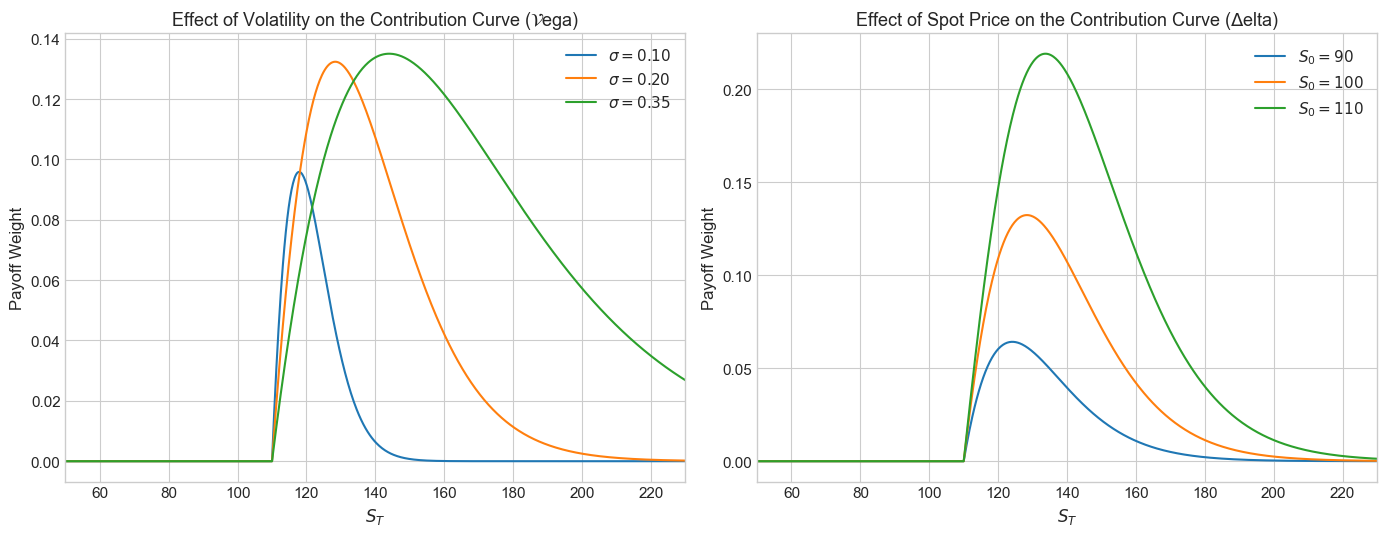

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
S_grid2 = np.linspace(40, 250, 1000)

# 1. Volatility Sensitivity (Vega Effect)
for sig in [0.10, 0.20, 0.35]:
    mu_sig = np.log(S0) + (r - q - 0.5 * sig**2) * T
    sigma_sig = sig * np.sqrt(T)
    f_sig = lognorm.pdf(S_grid2, s=sigma_sig, scale=np.exp(mu_sig))
    c_sig = np.maximum(S_grid2 - K, 0.0) * np.exp(-r * T) * f_sig
    axes[0].plot(S_grid2, c_sig, label=fr"$\sigma={sig:.2f}$")
axes[0].set_title(r"Effect of Volatility on the Contribution Curve ($\mathcal{V}$ega)")
axes[0].set_xlabel(r"$S_T$")
axes[0].set_ylabel("Payoff Weight")
axes[0].legend()
axes[0].set_xlim(50, 230)

# 2. Spot Price Sensitivity (Delta Effect)
for spot in [90.0, 100.0, 110.0]:
    mu_spot = np.log(spot) + (r - q - 0.5 * sigma**2) * T
    f_spot = lognorm.pdf(S_grid2, s=sigma_l, scale=np.exp(mu_spot))
    c_spot = np.maximum(S_grid2 - K, 0.0) * np.exp(-r * T) * f_spot
    axes[1].plot(S_grid2, c_spot, label=fr"$S_0={spot:.0f}$")
axes[1].set_title(r"Effect of Spot Price on the Contribution Curve ($\Delta$elta)")
axes[1].set_xlabel(r"$S_T$")
axes[1].set_ylabel("Payoff Weight")
axes[1].legend()
axes[1].set_xlim(50, 230)

plt.tight_layout()
plt.show()
